# FL Performance

Plot the performance of the global FL model, and the client's locals models.

### Imports

In [16]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Paths and load metrics

In [17]:
cwd = Path.cwd()
plot = cwd / 'plots'
base = cwd / 'runs'
path_iid = base / 'fluke_mnist_iid_30_rounds'
path_non_iid = base / 'fluke_mnist_non_iid_30_rounds'

def load_global_metrics(run_path: Path) -> pd.DataFrame:
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv'
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    raise FileNotFoundError(f'No global metrics CSV in {run_path}')

def load_comm_costs(run_path: Path):
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None

def load_run_time(run_path: Path):
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    if row.empty:
        return None
    return float(row['value'].iloc[0])

### Difference between IID and non-IID

✓ Plot saved at : c:\Users\bapti\Documents\INSA\S2\Cours\FL\TD-clean\plots\performance_iid.png


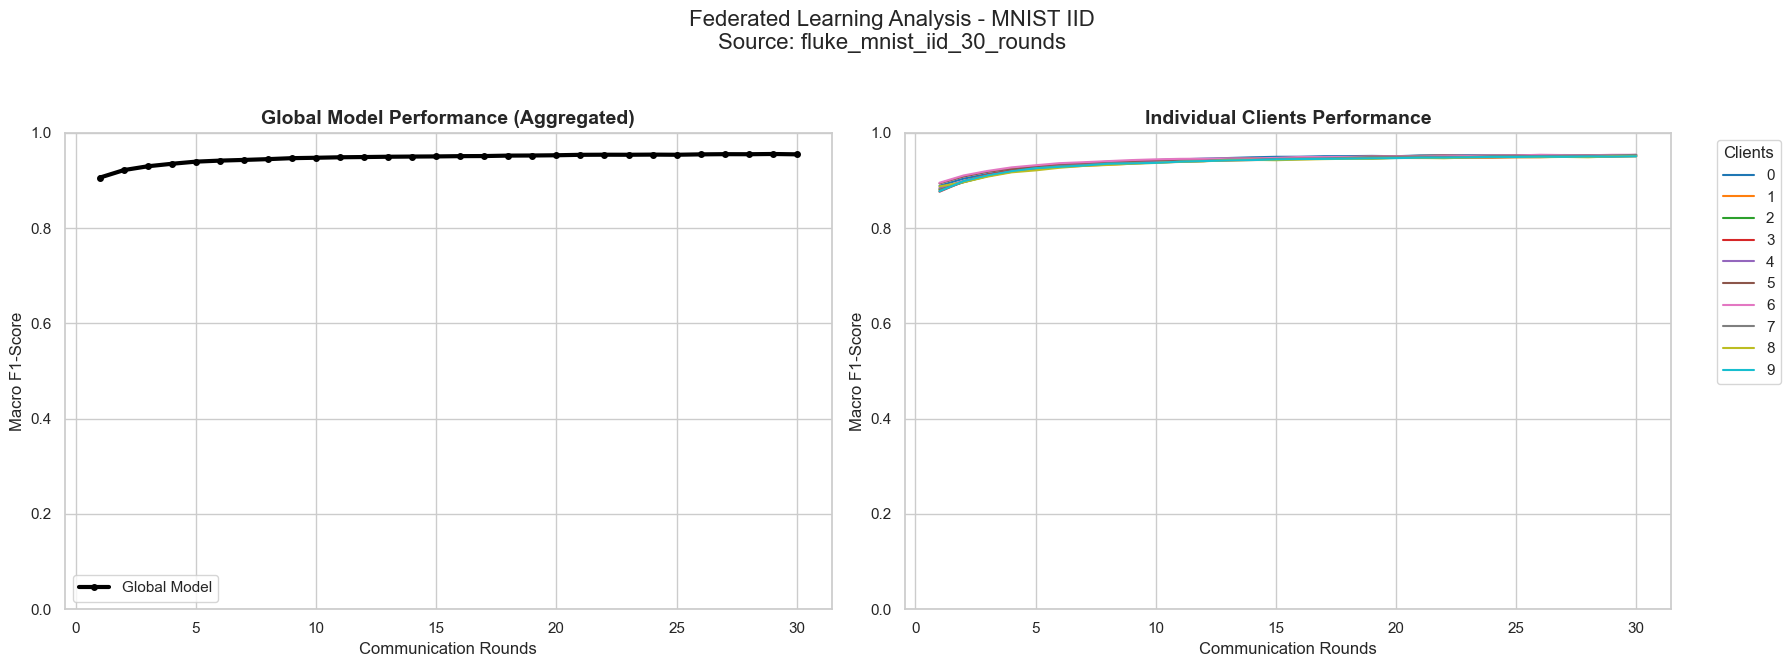

✓ Plot saved at : c:\Users\bapti\Documents\INSA\S2\Cours\FL\TD-clean\plots\performance_non_iid.png


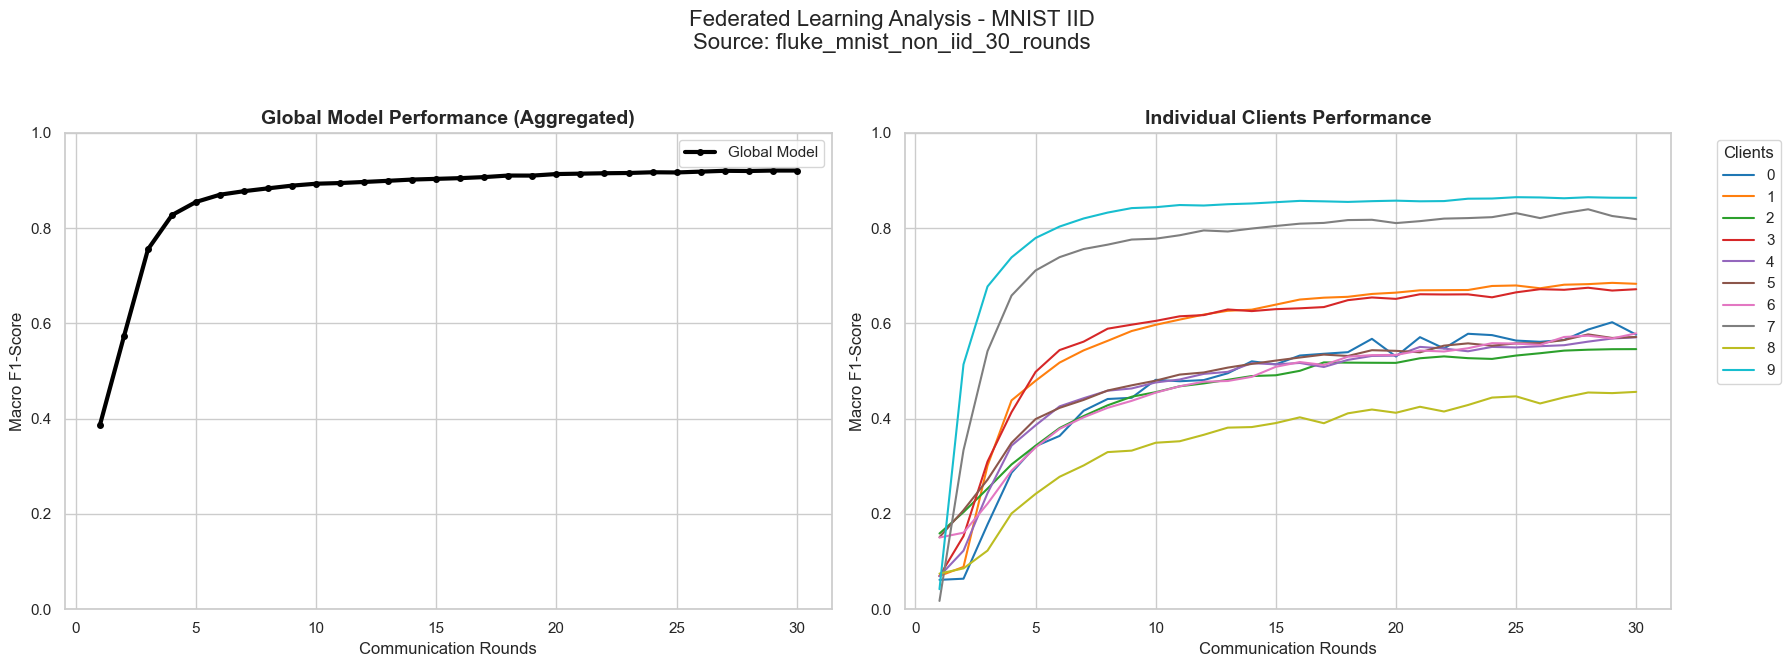

In [18]:
def plot_separate_performances(run_path: Path, save_plot: bool = True, output_name = Path):
    try:
        # 1. Load data
        df_global = pd.read_csv(run_path / 'global_metrics.csv')
        df_locals = pd.read_csv(run_path / 'locals_metrics.csv')

        # 2. Plotting
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
        sns.set_theme(style="whitegrid")

        # --- PLOT 1 : Global model ---
        ax1.plot(
            df_global['round'], 
            df_global['macro_f1'], 
            color='black', 
            linewidth=3, 
            marker='o', 
            markersize=4,
            label='Global Model'
        )
        ax1.set_title('Global Model Performance (Aggregated)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Communication Rounds')
        ax1.set_ylabel('Macro F1-Score')
        ax1.set_ylim(0, 1)
        ax1.legend()

        # --- PLOT 2 : All Clients ---
        sns.lineplot(
            data=df_locals, 
            x='round', 
            y='macro_f1', 
            hue='client', 
            palette='tab10', 
            linewidth=1.5,
            ax=ax2
        )
        ax2.set_title('Individual Clients Performance', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Communication Rounds')
        ax2.set_ylabel('Macro F1-Score')
        ax2.set_ylim(0, 1)
        
        ax2.legend(title='Clients', bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.suptitle(f"Federated Learning Analysis - MNIST IID\nSource: {run_path.name}", fontsize=16)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
        
        if save_plot:
            plt.savefig(output_name, dpi=300, bbox_inches='tight')
            print(f"✓ Plot saved at : {output_name}")
        
        plt.show()

    except Exception as e:
        print(f"Error during plot generation: {e}")

# --- Execution ---
if __name__ == "__main__":
        plot_separate_performances(path_iid, save_plot=True, output_name= plot / 'performance_iid.png')
        plot_separate_performances(path_non_iid, save_plot=True, output_name= plot / 'performance_non_iid.png')

### Comparison between FedAvg and SCAFFOLD

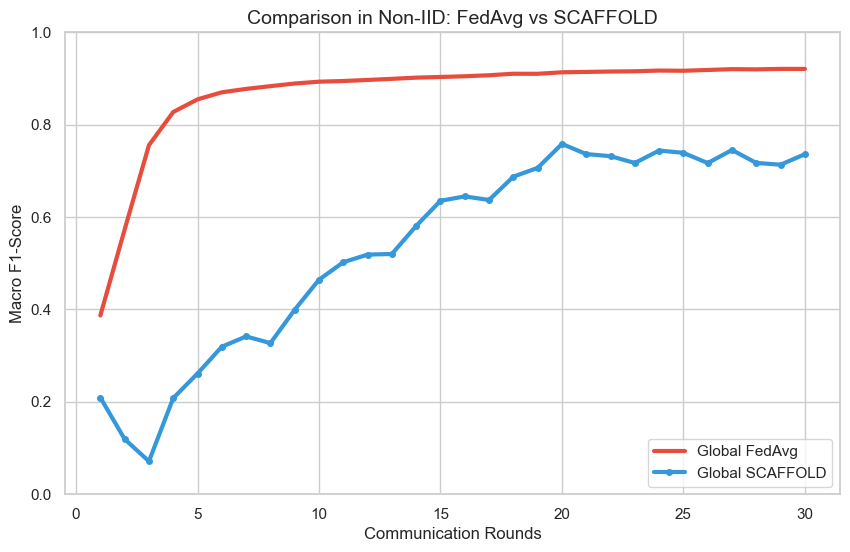

In [23]:
paths = {
    'non_iid_fedavg': base / 'fluke_mnist_non_iid_30_rounds',
    'non_iid_scaffold': base / 'fluke_mnist_non_iid_30_rounds_SCAFFOLD',
}

def compare_strategies(paths_dict, output_name = Path):
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    colors = {'fedavg': '#E74C3C', 'scaffold': '#3498DB'} 

    for label, run_path in paths_dict.items():
        if not run_path.exists():
            print(f"Path non trouvé : {run_path}")
            continue
            
        df_global = pd.read_csv(run_path / 'global_metrics.csv')
        
        algo_name = 'SCAFFOLD' if 'scaffold' in label.lower() else 'FedAvg'
        color = colors['scaffold'] if 'scaffold' in label.lower() else colors['fedavg']

        plt.plot(
            df_global['round'], 
            df_global['macro_f1'], 
            label=f'Global {algo_name}',
            color=color,
            linewidth=3,
            marker='o' if 'scaffold' in label.lower() else None,
            markersize=4
        )

    plt.title('Comparison in Non-IID: FedAvg vs SCAFFOLD', fontsize=14)
    plt.xlabel('Communication Rounds')
    plt.ylabel('Macro F1-Score')
    plt.ylim(0, 1)
    plt.legend()
    

    plt.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()

compare_strategies(paths, output_name=plot / 'comparison_fedavg_scaffold.png')

Using SCAFFOLD, with five local epochs, the correction error accumulates. After a few rounds, the “correction” becomes stronger than the learning itself. The model is instructed to modify its weights so drastically that it ends up not recognizing anything at all (it may predict the same class for all images, or its neurons may be “dead”). `comparison_fedavg_scaffold_CRASH.png`

To resolve this, a stabilization strategy was implemented. By reducing the learning rate to 0.01, limiting local computation to 1 epoch, and normalizing the global step to 1.0, the algorithm achieved stable convergence. These adjustments prevented the control variables from exploding and allowed SCAFFOLD to accurately estimate the required gradient corrections. `comparison_fedavg_scaffold.png`

The successful run demonstrates that while SCAFFOLD is significantly more sensitive to hyperparameters than FedAvg, its ability to mitigate client drift makes it a superior choice for heterogeneous data, provided the training dynamics are properly constrained.